# **Steel Industry Energy Consumption Prediction Using Machine Learning**




### Project Objective

The objective of this project is to analyze energy consumption patterns in the steel industry and develop machine learning regression models to predict energy consumption.

The project focuses on understanding the relationship between energy consumption and factors such as reactive power, power factor, CO₂ emissions, time-related features, week status, day of the week, and load type.

### Project Workflow

1. Problem Understanding
2. Import Required Libraries
3. Load Dataset
4. Understand the Dataset
5. Data Cleaning
6. Exploratory Data Analysis (EDA)
7. Data Visualization
8. Feature Engineering
9. Data Preprocessing
10. Train-Test Split
11. Model Building
12. Model Evaluation
13. Hyperparameter Tuning
14. Model Comparison
15. Best Model Selection
16. Save the Best Model
17. Business Insights
18. Conclusion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
# Upload the dataset
from google.colab import files
uploaded = files.upload()

Saving Steel_industry_data.csv to Steel_industry_data (1).csv


In [ ]:
# Loading the dataset
df = pd.read_csv("Steel_industry_data.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# Display the first five rows
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [ ]:
  # Checking the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 35040
Number of columns: 11


## Dataset Overview

The dataset contains 35,040 observations and 11 variables.

The variables contain information related to:

- Energy consumption
- Reactive power
- Power factor
- CO₂ emissions
- Time of day
- Weekday/weekend status
- Day of the week
- Load type

The target variable for this project is `Usage_kWh`.

In [ ]:
  # Displaying all column names

print("Columns in the dataset:\n")
for column in df.columns:
    print(column)

Columns in the dataset:

date
Usage_kWh
Lagging_Current_Reactive.Power_kVarh
Leading_Current_Reactive_Power_kVarh
CO2(tCO2)
Lagging_Current_Power_Factor
Leading_Current_Power_Factor
NSM
WeekStatus
Day_of_week
Load_Type


In [ ]:
# Checking data types of each column
df.dtypes

,0
date,object
Usage_kWh,float64
Lagging_Current_Reactive.Power_kVarh,float64
Leading_Current_Reactive_Power_kVarh,float64
CO2(tCO2),float64
Lagging_Current_Power_Factor,float64
Leading_Current_Power_Factor,float64
NSM,int64
WeekStatus,object
Day_of_week,object


In [ ]:
# Getting detailed information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

In [ ]:
# Statistical summary of numerical columns
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


## Statistical Summary

The statistical summary helps us understand the distribution of numerical variables.

It provides information such as:

- Count
- Mean
- Standard deviation
- Minimum value
- Maximum value
- Quartiles

This helps identify unusual values and understand the general behavior of the dataset.

In [ ]:
# Checking missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64


In [ ]:
# Checking duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Checking unique values in categorical columns

categorical_columns = ['WeekStatus', 'Day_of_week', 'Load_Type']
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 WeekStatus
['Weekday' 'Weekend']

 Day_of_week
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']

 Load_Type
['Light_Load' 'Medium_Load' 'Maximum_Load']


In [ ]:
# Converting date column into datetime format

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
print(df['date'].dtype)

datetime64[ns]


In [ ]:
# Extracting useful time-based features from the date column
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day
df['Hour'] = df['date'].dt.hour
df['Minute'] = df['date'].dt.minute
df['Day_of_Year'] = df['date'].dt.dayofyear

In [ ]:
# Converting the time into minutes from midnight
df['Time_in_Minutes'] = (
    df['date'].dt.hour * 60 +
    df['date'].dt.minute
)

In [ ]:
# Checking the target variable

print("Target variable: Usage_kWh")
print("\nMinimum Usage:", df['Usage_kWh'].min())
print("Maximum Usage:", df['Usage_kWh'].max())
print("Average Usage:", df['Usage_kWh'].mean())
print("Median Usage:", df['Usage_kWh'].median())

Target variable: Usage_kWh

Minimum Usage: 0.0
Maximum Usage: 157.18
Average Usage: 27.386892408675795
Median Usage: 4.57


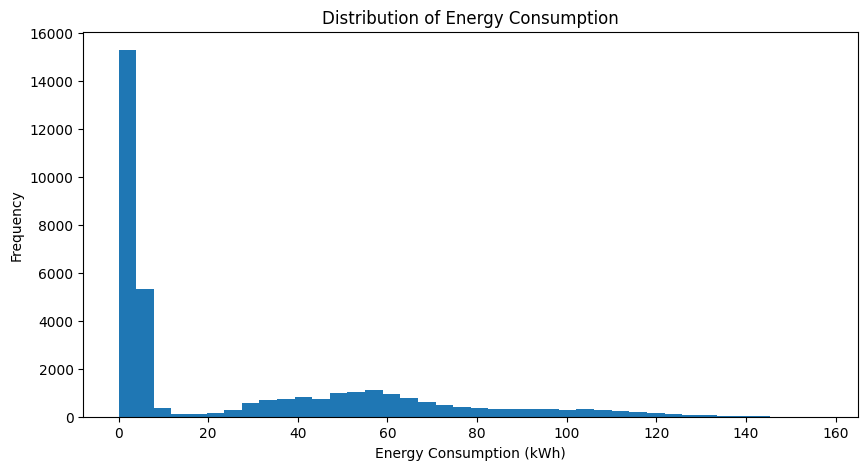

In [ ]:
# Distribution of energy consumption

plt.figure(figsize=(10, 5))

plt.hist(df['Usage_kWh'], bins=40)

plt.title('Distribution of Energy Consumption')
plt.xlabel('Energy Consumption (kWh)')
plt.ylabel('Frequency')
plt.show()

### Observation

The histogram shows how energy consumption is distributed across the observations.

Understanding the target distribution is important before building regression models because it helps identify whether the target has a relatively normal distribution or contains extreme values.

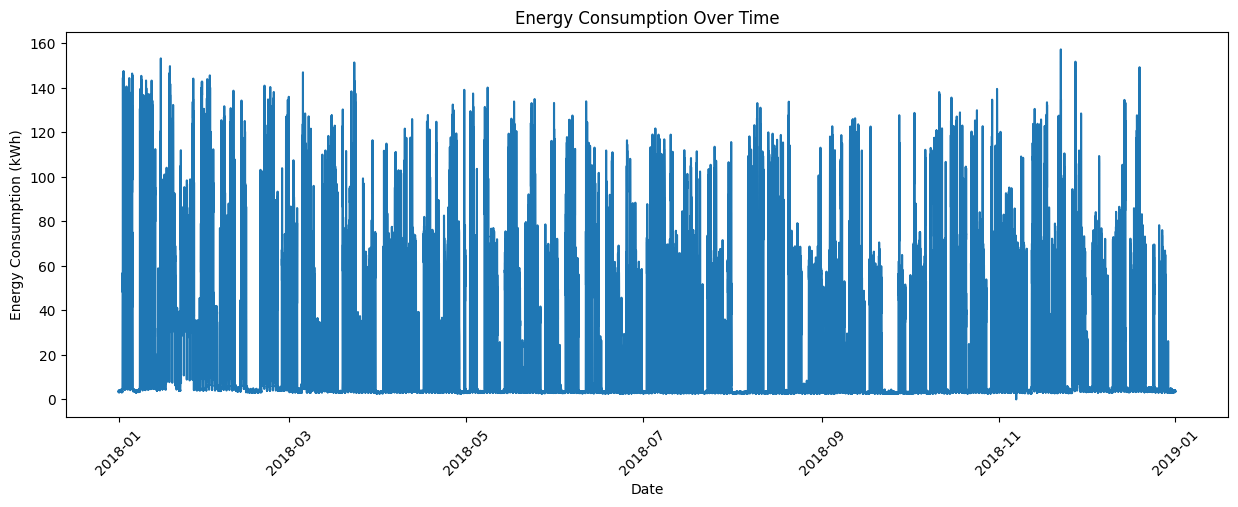

In [ ]:
# Sorting the dataset by date

df = df.sort_values('date')
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['Usage_kWh'])
plt.title('Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.xticks(rotation=45)
plt.show()

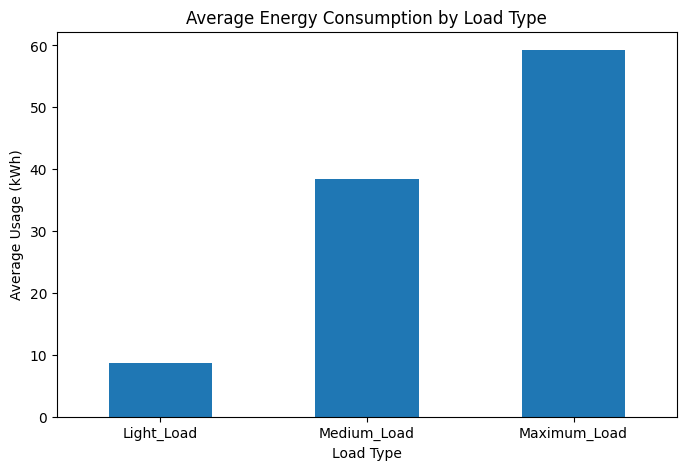

In [ ]:
# Average energy consumption by load type

load_consumption = df.groupby('Load_Type')['Usage_kWh'].mean().sort_values()
plt.figure(figsize=(8, 5))
load_consumption.plot(kind='bar')
plt.title('Average Energy Consumption by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Usage (kWh)')
plt.xticks(rotation=0)
plt.show()

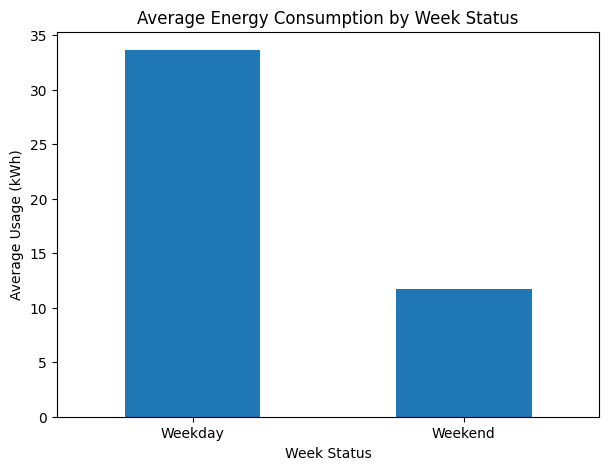

In [ ]:
# Average energy consumption by weekday/weekend status

week_consumption = df.groupby('WeekStatus')['Usage_kWh'].mean()
plt.figure(figsize=(7, 5))
week_consumption.plot(kind='bar')
plt.title('Average Energy Consumption by Week Status')
plt.xlabel('Week Status')
plt.ylabel('Average Usage (kWh)')
plt.xticks(rotation=0)
plt.show()

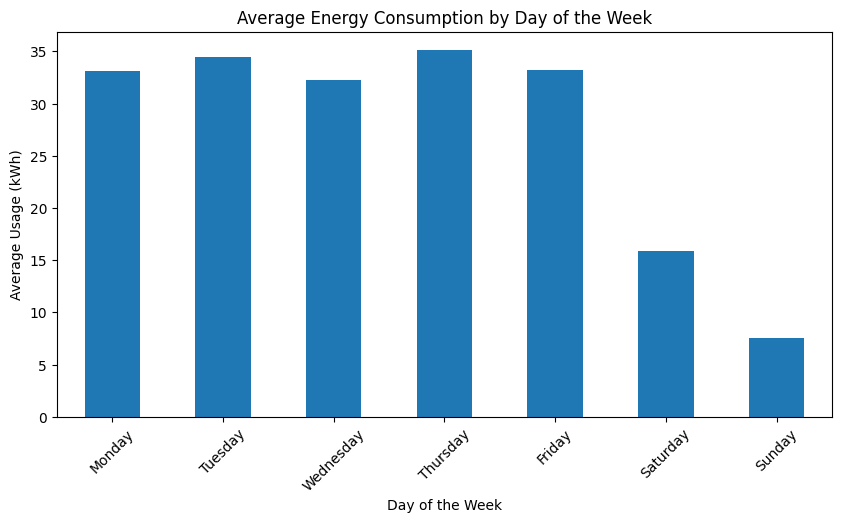

In [ ]:
# Average energy consumption by day of the week

day_consumption = df.groupby('Day_of_week')['Usage_kWh'].mean()
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_consumption = day_consumption.reindex(day_order)
plt.figure(figsize=(10, 5))
day_consumption.plot(kind='bar')
plt.title('Average Energy Consumption by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Usage (kWh)')
plt.xticks(rotation=45)
plt.show()

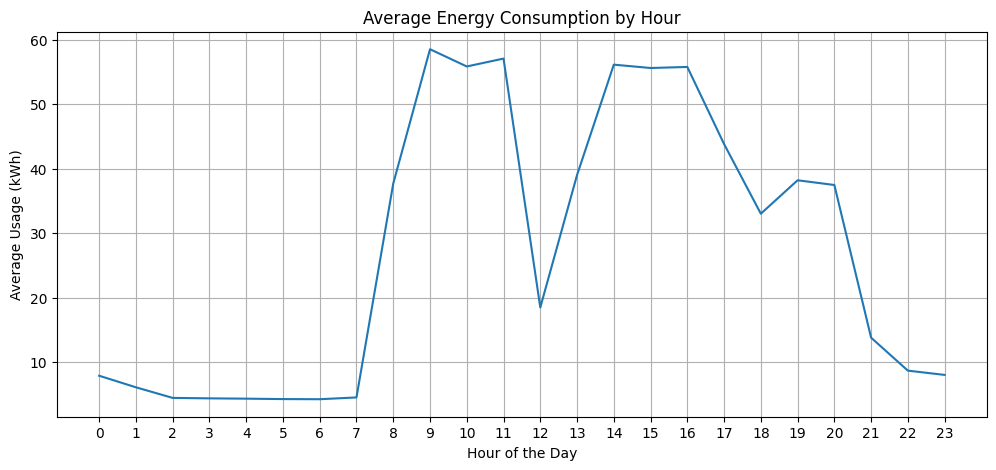

In [ ]:
# Average energy consumption by hour

hour_consumption = df.groupby('Hour')['Usage_kWh'].mean()
plt.figure(figsize=(12, 5))
hour_consumption.plot()
plt.title('Average Energy Consumption by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Usage (kWh)')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

In [ ]:
# Selecting numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Year,Month,Day,Hour,Minute,Day_of_Year,Time_in_Minutes
Usage_kWh,1.000000,0.896150,-0.324922,0.988180,0.385960,0.353566,2.346103e-01,NaN,-1.139607e-01,-8.170491e-03,2.341748e-01,1.552016e-02,-1.136272e-01,2.346103e-01
Lagging_Current_Reactive.Power_kVarh,0.896150,1.000000,-0.405142,0.886948,0.144534,0.407716,8.266237e-02,NaN,-4.213561e-02,-1.212823e-02,8.125047e-02,3.663487e-02,-4.258670e-02,8.266237e-02
Leading_Current_Reactive_Power_kVarh,-0.324922,-0.405142,1.000000,-0.332777,0.526770,-0.944039,3.716046e-01,NaN,-2.709951e-02,-1.366688e-02,3.727349e-01,-2.049372e-02,-2.817664e-02,3.716046e-01
CO2(tCO2),0.988180,0.886948,-0.332777,1.000000,0.379605,0.360019,2.317260e-01,NaN,-1.083105e-01,-6.095822e-04,2.313063e-01,1.507000e-02,-1.074203e-01,2.317260e-01
Lagging_Current_Power_Factor,0.385960,0.144534,0.526770,0.379605,1.000000,-0.519967,5.652695e-01,NaN,-8.705239e-02,2.568839e-02,5.665439e-01,-2.015353e-02,-8.406833e-02,5.652695e-01
Leading_Current_Power_Factor,0.353566,0.407716,-0.944039,0.360019,-0.519967,1.000000,-3.605630e-01,NaN,-3.232157e-02,7.403688e-03,-3.614087e-01,1.366848e-02,-3.152126e-02,-3.605630e-01
NSM,0.234610,0.082662,0.371605,0.231726,0.565270,-0.360563,1.000000e+00,NaN,3.135546e-16,5.597332e-17,9.991858e-01,4.034577e-02,3.460305e-16,1.000000e+00
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,-0.113961,-0.042136,-0.027100,-0.108311,-0.087052,-0.032322,3.135546e-16,NaN,1.000000e+00,1.189318e-02,6.993147e-15,3.462524e-15,9.965042e-01,8.869027e-15
Day,-0.008170,-0.012128,-0.013667,-0.000610,0.025688,0.007404,5.597332e-17,NaN,1.189318e-02,1.000000e+00,5.044895e-16,2.180806e-16,9.513102e-02,6.446785e-16


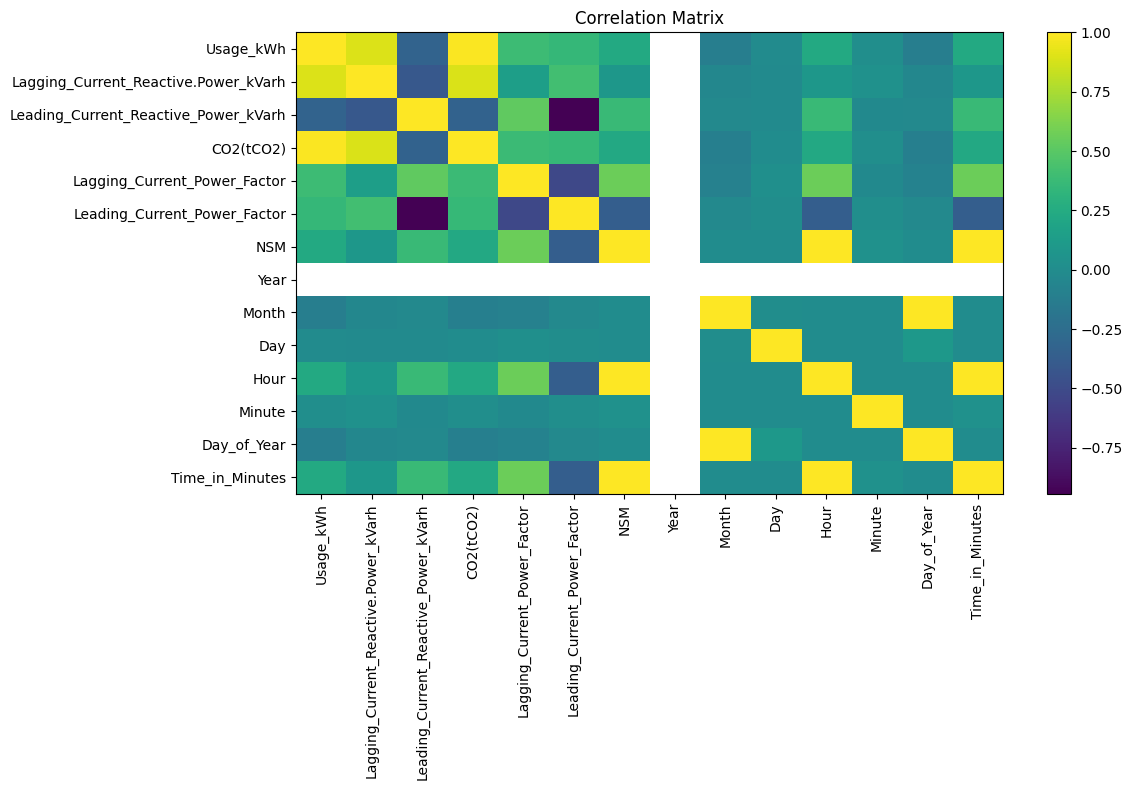

In [ ]:
plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar()
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Finding correlations with the target variable

target_correlation = (
    correlation_matrix['Usage_kWh']
    .sort_values(ascending=False)
)
target_correlation

,Usage_kWh
Usage_kWh,1.000000
CO2(tCO2),0.988180
Lagging_Current_Reactive.Power_kVarh,0.896150
Lagging_Current_Power_Factor,0.385960
Leading_Current_Power_Factor,0.353566
NSM,0.234610
Time_in_Minutes,0.234610
Hour,0.234175
Minute,0.015520
Day,-0.008170


## Correlation Analysis

Correlation helps us understand the strength and direction of the relationship between numerical variables and energy consumption.

A positive correlation indicates that two variables tend to increase together, while a negative correlation indicates an inverse relationship.

However, correlation does not necessarily imply causation.

In [ ]:
# Removing the original date column

model_df = df.drop(columns=['date'])
model_df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Year,Month,Day,Hour,Minute,Day_of_Year,Time_in_Minutes
95,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load,2018,1,1,0,0,1,0
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018,1,1,0,15,1,15
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018,1,1,0,30,1,30
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018,1,1,0,45,1,45
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,2018,1,1,1,0,1,60


In [ ]:
# Separating independent variables and target variable

X = model_df.drop(columns=['Usage_kWh'])
y = model_df['Usage_kWh']
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (35040, 16)
Target shape: (35040,)


In [ ]:
# Identifying categorical and numerical columns

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()
print("Categorical Features:")
print(categorical_features)
print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['WeekStatus', 'Day_of_week', 'Load_Type']

Numerical Features:
['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM']


In [ ]:
# Splitting the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (28032, 16)
Testing data: (7008, 16)


## Train-Test Split

The dataset is divided into two parts:

- **80% Training Data** – used to train the machine learning models.
- **20% Testing Data** – used to evaluate how well the trained models perform on unseen data.

A random state of 42 is used so that the same split can be reproduced.

In [ ]:
# Creating the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [ ]:
# Creating Linear Regression pipeline
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Training the model
linear_model.fit(X_train, y_train)

# Making predictions
linear_predictions = linear_model.predict(X_test)

In [ ]:
# Evaluating Linear Regression

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)
print("Linear Regression")
print("-----------------")
print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
-----------------
MAE : 2.555093342055314
MSE : 18.761313614162724
RMSE: 4.33143320555249
R²  : 0.9834348012750985


In [ ]:
# Creating Decision Tree Regression pipeline

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(
            random_state=42,
            max_depth=15
        ))
    ]
)

# Training the model
decision_tree_model.fit(X_train, y_train)

# Making predictions
dt_predictions = decision_tree_model.predict(X_test)

In [ ]:
# Evaluating Decision Tree

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)
print("Decision Tree Regression")
print("------------------------")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

Decision Tree Regression
------------------------
MAE : 0.6193853007859582
MSE : 2.1477420256819455
RMSE: 1.4655176647457873
R²  : 0.9981036629845371


In [ ]:
# Creating Random Forest Regression pipeline

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Training the model
random_forest_model.fit(X_train, y_train)

# Making predictions
rf_predictions = random_forest_model.predict(X_test)

In [ ]:
# Evaluating Random Forest

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)
print("Random Forest Regression")
print("------------------------")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regression
------------------------
MAE : 0.40033367829704425
MSE : 1.2055991156735175
RMSE: 1.09799777580536
R²  : 0.9989355228879805


In [ ]:
# Creating Gradient Boosting Regression pipeline

gradient_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ))
    ]
)

# Training the model
gradient_model.fit(X_train, y_train)

# Making predictions
gradient_predictions = gradient_model.predict(X_test)

In [ ]:
# Evaluating Gradient Boosting

gradient_mae = mean_absolute_error(
    y_test,
    gradient_predictions
)

gradient_mse = mean_squared_error(
    y_test,
    gradient_predictions
)

gradient_rmse = np.sqrt(gradient_mse)

gradient_r2 = r2_score(
    y_test,
    gradient_predictions
)
print("Gradient Boosting Regression")
print("----------------------------")
print("MAE :", gradient_mae)
print("MSE :", gradient_mse)
print("RMSE:", gradient_rmse)
print("R²  :", gradient_r2)

Gradient Boosting Regression
----------------------------
MAE : 1.320548097788276
MSE : 5.127976970898497
RMSE: 2.2645036919595642
R²  : 0.9954722809219752


In [ ]:
# Creating a model comparison table

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'MAE': [
        linear_mae,
        dt_mae,
        rf_mae,
        gradient_mae
    ],

    'MSE': [
        linear_mse,
        dt_mse,
        rf_mse,
        gradient_mse
    ],

    'RMSE': [
        linear_rmse,
        dt_rmse,
        rf_rmse,
        gradient_rmse
    ],

    'R2 Score': [
        linear_r2,
        dt_r2,
        rf_r2,
        gradient_r2
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest,0.400334,1.205599,1.097998,0.998936
1,Decision Tree,0.619385,2.147742,1.465518,0.998104
2,Gradient Boosting,1.320548,5.127977,2.264504,0.995472
3,Linear Regression,2.555093,18.761314,4.331433,0.983435


## Model Comparison

The models are compared using:

### MAE
Mean Absolute Error measures the average absolute difference between actual and predicted energy consumption.

### MSE
Mean Squared Error gives higher importance to larger prediction errors.

### RMSE
Root Mean Squared Error represents prediction error in the same unit as the target variable.

### R² Score
R² measures how much of the variation in energy consumption is explained by the model.

For this project:

- Lower MAE is better.
- Lower RMSE is better.
- Higher R² is better.

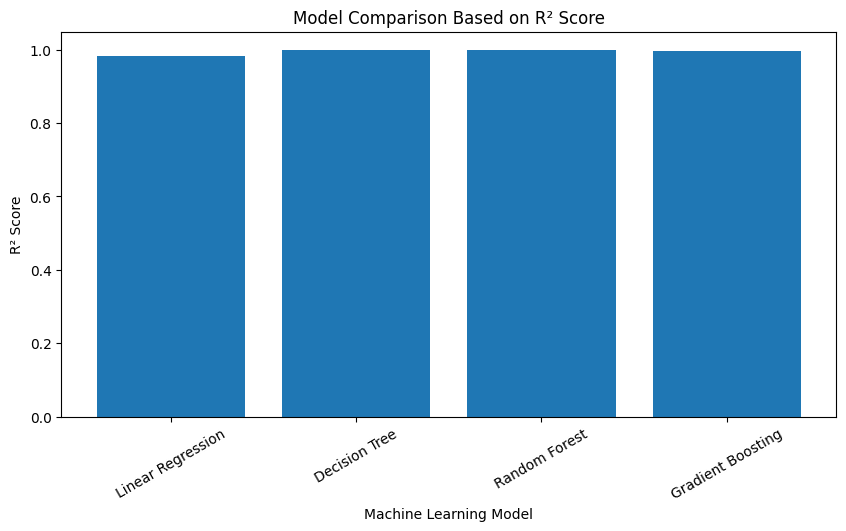

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results['Model'],
    results['R2 Score']
)

plt.title('Model Comparison Based on R² Score')
plt.xlabel('Machine Learning Model')
plt.ylabel('R² Score')
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Selecting the model with the highest R² score

best_model_name = results.loc[
    results['R2 Score'].idxmax(),
    'Model'
]
print("Best Model:", best_model_name)

Best Model: Random Forest


In [ ]:
# Selecting predictions according to the best model

if best_model_name == 'Linear Regression':
    best_model = linear_model
    best_predictions = linear_predictions

elif best_model_name == 'Decision Tree':
    best_model = decision_tree_model
    best_predictions = dt_predictions

elif best_model_name == 'Random Forest':
    best_model = random_forest_model
    best_predictions = rf_predictions

else:
    best_model = gradient_model
    best_predictions = gradient_predictions

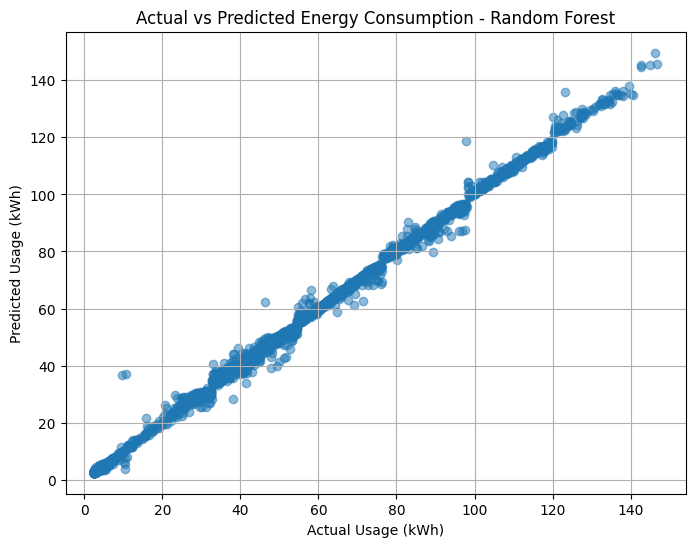

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')

plt.title(
    f'Actual vs Predicted Energy Consumption - {best_model_name}'
)

plt.grid()
plt.show()

In [ ]:
# Saving the best-performing model

joblib.dump(
    best_model,
    'steel_energy_best_model.pkl'
)
print("Best model saved successfully!")

Best model saved successfully!


In [ ]:
# Loading the saved model

loaded_model = joblib.load(
    'steel_energy_best_model.pkl'
)

# Testing the loaded model
sample_prediction = loaded_model.predict(
    X_test.head(5)
)
print("Sample predictions:")
print(sample_prediction)

Sample predictions:
[  2.62932442  66.81685798 109.10880136   3.21194993  48.37732022]


#  Key Insights

Based on the exploratory data analysis and machine learning results, the following insights were obtained:

1. Energy consumption varies across different load types.

2. Energy consumption also changes depending on the time of day.

3. Weekday and weekend energy consumption patterns show differences.

4. Electrical variables such as reactive power and power factor provide useful information for predicting energy consumption.

5. Time-based feature engineering helped the machine learning models understand daily and seasonal patterns.

6. Multiple regression models were developed and compared using MAE, MSE, RMSE and R² score.

7. The best-performing model was selected based on its overall predictive performance, with lower error values and a higher R² score.

8. The final model can be used as a predictive tool to estimate energy consumption based on available operational and electrical features.

#  Conclusion

In this project, machine learning techniques were applied to analyze and predict energy consumption in the steel industry.

The project started with data understanding and cleaning, followed by exploratory data analysis and visualization. Time-based features were extracted from the date column to improve the model's ability to identify energy consumption patterns.

Different machine learning regression algorithms, including Linear Regression, Decision Tree Regression, Random Forest Regression, and Gradient Boosting Regression, were trained and evaluated.

The models were compared using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

The best-performing model was selected based on the evaluation results and saved using Joblib.

This project demonstrates the complete machine learning workflow, from raw data preprocessing and exploratory analysis to model development, evaluation, and deployment-ready model saving.